In [2]:
import pandas as pd

food_df = pd.read_csv(r"C:\Users\DELL\nephrocare\data\processed\ifct2017_ckd_foods.csv")

print("Dataset Shape:", food_df.shape)

print("\nColumns:")
print(food_df.columns.tolist())

food_df.head()

import pandas as pd

food_df = pd.read_csv(r"C:\Users\DELL\nephrocare\data\processed\ifct2017_ckd_foods.csv")

print("Dataset Shape:", food_df.shape)

print("\nColumns:")
print(food_df.columns.tolist())

food_df.head()

Dataset Shape: (527, 7)

Columns:
['food_name', 'category', 'protein_g', 'energy_kcal', 'potassium_mg', 'phosphorus_mg', 'sodium_mg']
Dataset Shape: (527, 7)

Columns:
['food_name', 'category', 'protein_g', 'energy_kcal', 'potassium_mg', 'phosphorus_mg', 'sodium_mg']


,food_name,category,protein_g,energy_kcal,potassium_mg,phosphorus_mg,sodium_mg
0,"Amaranth seed, black (Amaranthus cruentus)",Cereals and millets,14.59,356.12,433.0,374.0,2.70
1,"Amaranth seed, pale brown (Amaranthus cruentus)",Cereals and millets,13.27,355.88,413.0,412.0,2.81
2,Bajra (Pennisetum typhoideum),Cereals and millets,10.96,347.99,365.0,289.0,4.11
3,Barley (Hordeum vulgare),Cereals and millets,10.94,315.73,268.0,178.0,7.56
4,Jowar (Sorghum vulgare),Cereals and millets,9.97,334.13,328.0,274.0,5.42


In [3]:
# Add CKD safety category for every food

def classify_food(row):

    if (
        row["potassium_mg"] <= 200 and
        row["phosphorus_mg"] <= 150 and
        row["sodium_mg"] <= 140
    ):
        return "Safe"

    elif (
        row["potassium_mg"] <= 350 and
        row["phosphorus_mg"] <= 250 and
        row["sodium_mg"] <= 300
    ):
        return "Moderate"

    else:
        return "Avoid"


food_df["safety"] = food_df.apply(
    classify_food,
    axis=1
)

food_df["safety"].value_counts()

safety
Avoid       226
Moderate    221
Safe         80
Name: count, dtype: int64

<Axes: xlabel='safety'>

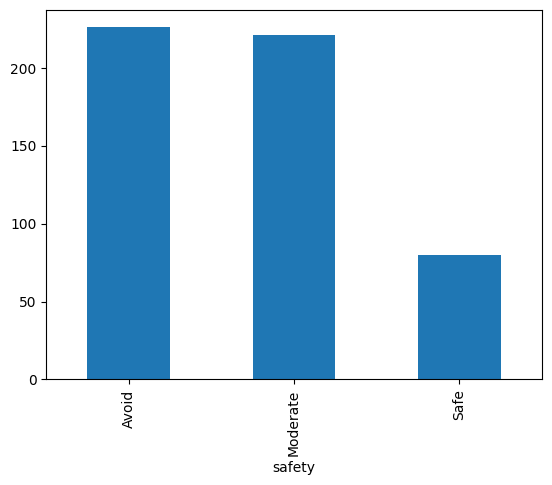

In [4]:
food_df["safety"].value_counts().plot(
    kind="bar"
)

In [7]:
# Recommend foods based on CKD stage

def recommend_foods(stage, top_n=20):

    if stage >= 4:

        recommendations = food_df[
            food_df["safety"] == "Safe"
        ]

    else:

        recommendations = food_df[
            food_df["safety"].isin(
                ["Safe", "Moderate"]
            )
        ]

    recommendations = recommendations.sort_values(
        by=[
            "potassium_mg",
            "phosphorus_mg",
            "sodium_mg"
        ]
    )

    return recommendations.head(top_n)

In [8]:
stage5_foods = recommend_foods(
    stage=5
)

stage5_foods[
    [
        "food_name",
        "category",
        "protein_g",
        "potassium_mg",
        "phosphorus_mg",
        "sodium_mg",
        "safety"
    ]
]

,food_name,category,protein_g,potassium_mg,phosphorus_mg,sodium_mg,safety
355,"Goat, tripe",Animal meat,15.36,45.00,59.20,22.38,Safe
203,Mangosteen (Garcinia mangostana),Fruits,0.63,46.93,7.18,3.79,Safe
368,"Sheep, tripe",Animal meat,16.76,48.75,55.61,18.37,Safe
155,"Tinda, tender (Praecitrullus fistulosus)",Other vegetables,1.02,56.18,30.37,20.61,Safe
307,Toddy (Borassus flabellifer),Miscellaneous foods,0.18,83.54,5.82,1.64,Safe
154,"Snake gourd, short (Trichosanthes anguina)",Other vegetables,0.54,84.00,21.33,2.50,Safe
16,Varagu (Paspalum scrobiculatum),Cereals and millets,8.92,94.00,101.00,3.35,Safe
162,"Apple, green (Malus domestica)",Fruits,0.46,94.55,7.48,1.47,Safe
166,"Apricot, processed (Prunus armeniaca)",Fruits,1.47,95.00,27.33,1.60,Safe
163,"Apple, small (Malus domestica)",Fruits,0.31,100.00,8.39,1.45,Safe


In [9]:
stage3_foods = recommend_foods(
    stage=3
)

stage3_foods[
    [
        "food_name",
        "category",
        "protein_g",
        "potassium_mg",
        "phosphorus_mg",
        "sodium_mg",
        "safety"
    ]
]

,food_name,category,protein_g,potassium_mg,phosphorus_mg,sodium_mg,safety
355,"Goat, tripe",Animal meat,15.36,45.00,59.20,22.38,Safe
203,Mangosteen (Garcinia mangostana),Fruits,0.63,46.93,7.18,3.79,Safe
368,"Sheep, tripe",Animal meat,16.76,48.75,55.61,18.37,Safe
155,"Tinda, tender (Praecitrullus fistulosus)",Other vegetables,1.02,56.18,30.37,20.61,Safe
307,Toddy (Borassus flabellifer),Miscellaneous foods,0.18,83.54,5.82,1.64,Safe
154,"Snake gourd, short (Trichosanthes anguina)",Other vegetables,0.54,84.00,21.33,2.50,Safe
16,Varagu (Paspalum scrobiculatum),Cereals and millets,8.92,94.00,101.00,3.35,Safe
162,"Apple, green (Malus domestica)",Fruits,0.46,94.55,7.48,1.47,Safe
166,"Apricot, processed (Prunus armeniaca)",Fruits,1.47,95.00,27.33,1.60,Safe
163,"Apple, small (Malus domestica)",Fruits,0.31,100.00,8.39,1.45,Safe


In [11]:
def search_food(food_name):

    result = food_df[
        food_df["food_name"]
        .str.lower()
        .str.contains(
            food_name.lower(),
            na=False
        )
    ]

    return result[
        [
            "food_name",
            "category",
            "protein_g",
            "energy_kcal",
            "potassium_mg",
            "phosphorus_mg",
            "sodium_mg",
            "safety"
        ]
    ]

In [12]:
search_food("Rice")

,food_name,category,protein_g,energy_kcal,potassium_mg,phosphorus_mg,sodium_mg,safety
10,Rice flakes (poha) (Oryza sativa),Cereals and millets,7.44,353.73,148.0,195.0,2.58,Moderate
11,Rice puffed (Oryza sativa),Cereals and millets,7.47,361.85,140.0,152.0,3.69,Moderate
12,"Rice, raw, brown (Oryza sativa)",Cereals and millets,9.16,353.73,199.0,267.0,3.64,Avoid
13,"Rice, parboiled, milled (Oryza sativa)",Cereals and millets,7.81,351.58,142.0,140.0,3.16,Safe
14,"Rice, raw, milled (Oryza sativa)",Cereals and millets,7.94,356.36,108.0,96.0,2.34,Safe
46,Ricebean (Vigna umbellata),Grain legumes,19.97,302.34,1196.0,270.0,10.62,Avoid


In [13]:
food_df.to_csv(
    "data/processed/indian_ckd_foods.csv",
    index=False
)

print("Food recommendation dataset saved")

Food recommendation dataset saved


In [14]:
# Vegetarian / Non-Vegetarian tagging

non_veg_keywords = [
    "fish",
    "chicken",
    "mutton",
    "egg",
    "beef",
    "pork",
    "meat",
    "prawn",
    "shrimp"
]

def get_diet_type(food):

    food = str(food).lower()

    for keyword in non_veg_keywords:
        if keyword in food:
            return "Non-Vegetarian"

    return "Vegetarian"

food_df["diet_type"] = food_df["food_name"].apply(
    get_diet_type
)

food_df["diet_type"].value_counts()

diet_type
Vegetarian        459
Non-Vegetarian     68
Name: count, dtype: int64

In [16]:
# Personalized recommendations

def recommend_foods_v2(
    stage,
    diet_type="Vegetarian",
    min_protein=0,
    top_n=20
):

    data = food_df.copy()

    if stage >= 4:

        data = data[
            data["safety"] == "Safe"
        ]

    else:

        data = data[
            data["safety"].isin(
                ["Safe", "Moderate"]
            )
        ]

    data = data[
        data["diet_type"] == diet_type
    ]

    data = data[
        data["protein_g"] >= min_protein
    ]

    score = (
        data["protein_g"] * 2
        - data["potassium_mg"] * 0.01
        - data["phosphorus_mg"] * 0.01
        - data["sodium_mg"] * 0.01
    )

    data["recommendation_score"] = score

    data = data.sort_values(
        by="recommendation_score",
        ascending=False
    )

    return data.head(top_n)

In [17]:
recommend_foods_v2(
    stage=5,
    diet_type="Vegetarian",
    min_protein=5,
    top_n=15
)[
    [
        "food_name",
        "protein_g",
        "potassium_mg",
        "phosphorus_mg",
        "sodium_mg",
        "recommendation_score"
    ]
]

,food_name,protein_g,potassium_mg,phosphorus_mg,sodium_mg,recommendation_score
368,"Sheep, tripe",16.76,48.75,55.61,18.37,32.2927
355,"Goat, tripe",15.36,45.00,59.20,22.38,29.4542
358,"Goat, tube (small intestine)",12.92,130.00,55.90,7.46,23.9064
17,"Wheat flour, refined (Triticum aestivum)",10.36,148.00,110.00,1.54,18.1246
23,"Wheat, vermicelli, roasted (Triticum aestivum)",10.37,177.00,107.00,3.43,17.8657
15,Samai (Panicum miliare),10.13,105.00,130.00,4.77,17.8623
22,"Wheat, vermicelli (Triticum aestivum)",9.70,163.00,99.00,2.71,16.7529
16,Varagu (Paspalum scrobiculatum),8.92,94.00,101.00,3.35,15.8565
14,"Rice, raw, milled (Oryza sativa)",7.94,108.00,96.00,2.34,13.8166
13,"Rice, parboiled, milled (Oryza sativa)",7.81,142.00,140.00,3.16,12.7684


In [18]:
high_protein = food_df.sort_values(
    by="protein_g",
    ascending=False
)

high_protein[
    [
        "food_name",
        "protein_g",
        "safety"
    ]
].head(20)

,food_name,protein_g,safety
48,"Soybean, white (Glycine max)",37.80,Avoid
47,"Soybean, brown (Glycine max)",35.58,Avoid
272,Fenugreek seeds (Trigonella foenum graecum),25.41,Avoid
501,"Eggs, Cat fish (Ompok bimaculatus)",24.68,Avoid
493,Tuna (Euthynnus affinis),24.50,Avoid
36,Lentil dal (Lens culinaris),24.35,Avoid
489,Stingray (Dasyatis pastinaca),23.98,Moderate
33,"Green gram, dal (Vigna radiata)",23.88,Avoid
440,Korka (Terapon jarbua),23.72,Moderate
446,Milk fish (Chanos chanos),23.66,Avoid


In [19]:
# category wise food
food_df["category"].value_counts().head(20)

category
Marine fish                      92
Other vegetables                 78
Fruits                           67
Animal meat                      63
Green leafy vegetables           34
Condiments and spices            33
Grain legumes                    25
Cereals and millets              24
Nuts and oil seeds               21
Roots and tubers                 19
Poultry                          19
Egg and egg products             15
Freshwater fish and shellfish    10
Marine shellfish                  8
Marine mollusks                   7
Mushrooms                         4
Milk and milk products            4
Miscellaneous foods               2
Sugars                            2
Name: count, dtype: int64

In [20]:
def recommend_by_category(
    category,
    stage=5,
    top_n=10
):

    foods = recommend_foods_v2(
        stage=stage,
        top_n=100
    )

    foods = foods[
        foods["category"]
        .str.contains(
            category,
            case=False,
            na=False
        )
    ]

    return foods.head(top_n)

In [21]:
recommend_by_category(
    "Vegetables",
    stage=5
)

,food_name,category,protein_g,energy_kcal,potassium_mg,phosphorus_mg,sodium_mg,safety,diet_type,recommendation_score
85,"Bean scarlet, tender (Phaseolus coccineus)",Other vegetables,2.86,42.78,164.00,62.13,1.46,Safe,Vegetarian,3.4441
71,"Gogu leaves, red (Hibiscus cannabinus)",Green leafy vegetables,1.85,36.57,161.00,36.38,14.08,Safe,Vegetarian,1.5854
142,Parwar (Trichosanthes dioica),Other vegetables,1.40,24.14,117.00,33.81,2.29,Safe,Vegetarian,1.2690
160,"Zucchini, yellow (Cucurbita pepo)",Other vegetables,1.31,18.88,131.00,32.03,0.39,Safe,Vegetarian,0.9858
155,"Tinda, tender (Praecitrullus fistulosus)",Other vegetables,1.02,13.86,56.18,30.37,20.61,Safe,Vegetarian,0.9684
152,"Snake gourd, long, pale green (Trichosanthes a...",Other vegetables,0.98,12.43,100.00,23.27,7.07,Safe,Vegetarian,0.6566
94,Brinjal-3 (Solanum melongena),Other vegetables,1.36,24.38,192.00,27.79,3.12,Safe,Vegetarian,0.4909
137,"Kovai, small (Coccinia cordifolia)",Other vegetables,1.22,19.12,167.00,26.29,2.20,Safe,Vegetarian,0.4851
115,"Capsicum, green (Capsicum annuum)",Other vegetables,1.11,16.25,154.00,23.00,1.84,Safe,Vegetarian,0.4316
136,"Kovai, big (Coccinia cordifolia)",Other vegetables,1.39,17.45,198.00,36.90,1.53,Safe,Vegetarian,0.4157


In [22]:
def calculate_food_score(row):

    score = 100

    score -= row["potassium_mg"] * 0.05
    score -= row["phosphorus_mg"] * 0.05
    score -= row["sodium_mg"] * 0.05

    score += row["protein_g"] * 1

    return max(0, min(100, score))


food_df["kidney_score"] = food_df.apply(
    calculate_food_score,
    axis=1
)

food_df[
    [
        "food_name",
        "kidney_score"
    ]
].head()

,food_name,kidney_score
0,"Amaranth seed, black (Amaranthus cruentus)",74.1050
1,"Amaranth seed, pale brown (Amaranthus cruentus)",71.8795
2,Bajra (Pennisetum typhoideum),78.0545
3,Barley (Hordeum vulgare),88.2620
4,Jowar (Sorghum vulgare),79.5990


In [23]:
# Top Kidney Friendly Foods
food_df.sort_values(
    by="kidney_score",
    ascending=False
)[
    [
        "food_name",
        "category",
        "kidney_score",
        "safety"
    ]
].head(25)

,food_name,category,kidney_score,safety
485,Silan (Silonia silondia),Marine fish,100.0000,Moderate
447,Moon fish (Mene maculata),Marine fish,100.0000,Moderate
358,"Goat, tube (small intestine)",Animal meat,100.0000,Safe
355,"Goat, tripe",Animal meat,100.0000,Safe
379,"Beef, tripe",Animal meat,100.0000,Safe
368,"Sheep, tripe",Animal meat,100.0000,Safe
488,Sole fish (Cynoglossus arel),Marine fish,99.2215,Safe
16,Varagu (Paspalum scrobiculatum),Cereals and millets,99.0025,Safe
487,Silver carp (Hypophthalmichthys molitrix),Marine fish,98.9300,Moderate
403,"Pork, tube (small intestine)",Animal meat,98.7515,Safe


In [24]:
# Save Final Engine Dataset
food_df.to_csv(
    "data/processed/final_food_recommendation_engine.csv",
    index=False
)

print("Food recommendation engine ready")

Food recommendation engine ready


In [57]:
# CKD nutrition limits by stage

ckd_limits = {

    1: {
        "max_potassium": 3500,
        "max_phosphorus": 1400,
        "max_sodium": 2300
    },

    2: {
        "max_potassium": 3000,
        "max_phosphorus": 1200,
        "max_sodium": 2000
    },

    3: {
        "max_potassium": 2000,
        "max_phosphorus": 1000,
        "max_sodium": 1500
    },

    4: {
        "max_potassium": 1800,
        "max_phosphorus": 900,
        "max_sodium": 1200
    },

    5: {
        "max_potassium": 1500,
        "max_phosphorus": 800,
        "max_sodium": 1000
    }
}

In [58]:
# Create food groups for meal planning

def get_food_group(category):

    category = str(category).lower()

    if category in [
        "cereals and millets",
        "roots and tubers"
    ]:
        return "Carbs"

    elif category in [
        "grain legumes",
        "milk and milk products",
        "egg and egg products"
    ]:
        return "Protein"

    elif category in [
        "other vegetables",
        "green leafy vegetables",
        "mushrooms"
    ]:
        return "Vegetable"

    elif category == "fruits":
        return "Fruit"

    else:
        return "Other"


food_df["food_group"] = food_df["category"].apply(
    get_food_group
)

food_df["food_group"].value_counts()

food_group
Other        257
Vegetable    116
Fruit         67
Protein       44
Carbs         43
Name: count, dtype: int64

In [59]:
# Remove foods that don't belong in meal plans

bad_keywords = [
    "tripe",
    "intestine",
    "tube",
    "shellfish",
    "mollusk"
]

food_df = food_df[
    ~food_df["food_name"]
    .str.lower()
    .str.contains(
        "|".join(bad_keywords),
        na=False
    )
]

In [60]:
def generate_meal_plan(
    calorie_target,
    ckd_stage=3
):

    limits = ckd_limits[ckd_stage]

    foods = food_df.copy()

    foods = foods[
        foods["potassium_mg"]
        <= limits["max_potassium"] / 4
    ]

    foods = foods[
        foods["phosphorus_mg"]
        <= limits["max_phosphorus"] / 4
    ]

    foods = foods[
        foods["sodium_mg"]
        <= limits["max_sodium"] / 4
    ]

    foods = foods.sort_values(
        by="kidney_score",
        ascending=False
    )

    breakfast = []
    lunch = []
    dinner = []

    used_foods = set()

    def get_food(group):

        candidates = foods[
            (foods["food_group"] == group)
            &
            (~foods["food_name"].isin(
                used_foods
            ))
        ]

        if len(candidates) == 0:
            return None

        food = candidates.iloc[0]

        used_foods.add(
            food["food_name"]
        )

        return food

    # Breakfast

    breakfast.extend([
        get_food("Carbs"),
        get_food("Fruit")
    ])

    # Lunch

    lunch.extend([
        get_food("Carbs"),
        get_food("Vegetable"),
        get_food("Protein")
    ])

    # Dinner

    dinner.extend([
        get_food("Carbs"),
        get_food("Vegetable"),
        get_food("Fruit")
    ])

    breakfast = [
        x for x in breakfast
        if x is not None
    ]

    lunch = [
        x for x in lunch
        if x is not None
    ]

    dinner = [
        x for x in dinner
        if x is not None
    ]

    return {
        "Breakfast": breakfast,
        "Lunch": lunch,
        "Dinner": dinner,
        "Target Calories": calorie_target
    }

In [61]:
def meal_nutrition(plan):

    selected_foods = []

    for meal_name in [
        "Breakfast",
        "Lunch",
        "Dinner"
    ]:

        foods = plan[meal_name]

        for food in foods:

            selected_foods.append(
                food["food_name"]
            )

    selected_df = food_df[
        food_df["food_name"].isin(
            selected_foods
        )
    ]

    return pd.DataFrame({

        "Target Calories":[
            plan["Target Calories"]
        ],

        "Actual Calories":[
            round(
                selected_df["energy_kcal"].sum(),
                2
            )
        ],

        "Protein_g":[
            round(
                selected_df["protein_g"].sum(),
                2
            )
        ],

        "Potassium_mg":[
            round(
                selected_df["potassium_mg"].sum(),
                2
            )
        ],

        "Phosphorus_mg":[
            round(
                selected_df["phosphorus_mg"].sum(),
                2
            )
        ],

        "Sodium_mg":[
            round(
                selected_df["sodium_mg"].sum(),
                2
            )
        ]
    })

In [62]:
calorie_target = int(
    input("Enter target calories: ")
)

ckd_stage = int(
    input("Enter CKD Stage (1-5): ")
)

Enter target calories:  2000
Enter CKD Stage (1-5):  3


In [63]:
plan = generate_meal_plan(
    calorie_target=calorie_target,
    ckd_stage=ckd_stage
)

print("=" * 50)
print("CKD PERSONALIZED MEAL PLAN")
print("=" * 50)

for meal_name in [
    "Breakfast",
    "Lunch",
    "Dinner"
]:

    print(f"\n{meal_name.upper()}")

    for food in plan[meal_name]:

        print(
            "•",
            food["food_name"]
        )

CKD PERSONALIZED MEAL PLAN

BREAKFAST
• Varagu (Paspalum scrobiculatum)
• Mangosteen (Garcinia mangostana)

LUNCH
• Samai (Panicum miliare)
• Tinda, tender (Praecitrullus fistulosus)
• Egg, poultry, white, boiled

DINNER
• Rice, raw, milled (Oryza sativa)
• Snake gourd, short (Trichosanthes anguina)
• Apple, green (Malus domestica)


In [64]:
summary = meal_nutrition(plan)

print("\nNUTRITION SUMMARY")

display(summary)


NUTRITION SUMMARY


,Target Calories,Actual Calories,Protein_g,Potassium_mg,Phosphorus_mg,Sodium_mg
0,2000,1218.93,42.01,735.66,416.36,182.83
